In [12]:
# See how you can use images created from a FalconEditor simulation to train a
# YOLO_v8 model, then test the model on real world images.

# Read the comment instructions and run this colab notebook to see synthetic
# data work on real world images.

# FalconEditor allows users to easily create synthetic datasets tailored to
# their training needs. The FalconEDU subscription provides support (like this!)
# for training and testing.

# With FalconEDU, you have the instructions and software needed to
# create your own simulation, learn best practices for synthetic data and
# simualation, and collaborate with other learners and experts.


import os, sys
HOME = os.getcwd()
print(HOME)

/content/drive/MyDrive/syntheticDataWorks_multiclass/Output


In [13]:
# Start with running a GPU enabled instance.  If this
# fails, go to the Edit menu, choose 'Notebook settings' and select a 'T4 GPU'
# under Hardware Accelerator.

# The GPU makes the training go MUCH faster, so it's worth setting up now.

# Not everyone has a GPU enabled computer, and even if you do, Colab still make
# the process easier.

# The FalconEDU subscription contains tips, tricks, and advice for making
# simulation using digital twins, synthetic data, and AI training easier, better,
# and faster!

!nvidia-smi

Sun Apr 19 12:37:52 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   78C    P0             34W /   70W |    1085MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [14]:
# Now we install Ultralytics, the specific python version, and
# CUDA. These are all files needed for training.

# Using Colab prevents you from installing/uninstalling software
# versions, thereby bypassing potential conflicts. Our EDU support
# content helps you navigate these type of hurdles.

# Uninstall and reinstall packages with compatible versions
!pip uninstall numpy -y -q
!pip install numpy==1.26.4 -q
!pip install ultralytics==8.2.103 -q

from IPython import display
display.clear_output

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 46.4/112.6 GB disk)


In [15]:
# Now we mount (connect) the folder on Drive containing the training data.
# You will have to grant Colab access the drive connected to this Colab Notebook.
# After running the code below, the system will access for credentials - enter
# the ones for the particular Google account that controls the folder that
# contains the Falcon datasets.

# Note:  You may find that this does not work if the notebook and the Drive
# folder are owned by different Google accounts.

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
DRIVE_ROOT = Path('/content/drive/MyDrive')

# Update SOURCE_PROJECT_ROOT to the shared folder path that contains the dataset.
# Example: SOURCE_PROJECT_ROOT = DRIVE_ROOT / 'Shared with me' / 'syntheticDataWorks_multiclass'
SOURCE_PROJECT_ROOT = DRIVE_ROOT / 'syntheticDataWorks_multiclass'

DEST_PROJECT_FOLDER = 'syntheticDataWorks_multiclass'
DEST_PROJECT_ROOT = DRIVE_ROOT / DEST_PROJECT_FOLDER

if not SOURCE_PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f'Source project folder not found: {SOURCE_PROJECT_ROOT}\n'
        'Update SOURCE_PROJECT_ROOT to the folder that contains your shared dataset.'
    )

if SOURCE_PROJECT_ROOT.resolve() == DEST_PROJECT_ROOT.resolve():
    print('Source and destination are identical. Using the shared folder directly.')
else:
    if not DEST_PROJECT_ROOT.exists():
        import shutil
        print('Copying project from', SOURCE_PROJECT_ROOT, 'to', DEST_PROJECT_ROOT)
        shutil.copytree(SOURCE_PROJECT_ROOT, DEST_PROJECT_ROOT)
        print('Copy complete.')
    else:
        print('Destination already exists at', DEST_PROJECT_ROOT)

PROJECT_ROOT = DEST_PROJECT_ROOT
OUTPUT_DIR = PROJECT_ROOT / 'Output'
assert OUTPUT_DIR.exists(), f'Expected Output directory missing: {OUTPUT_DIR}'
print('Using project root:', PROJECT_ROOT)
print('Using output directory:', OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Source and destination are identical. Using the shared folder directly.
Using project root: /content/drive/MyDrive/syntheticDataWorks_multiclass
Using output directory: /content/drive/MyDrive/syntheticDataWorks_multiclass/Output


In [16]:
# Change directory to the project folder in your mounted Drive.
# If your folder is not under MyDrive, update PROJECT_FOLDER above.

%cd {OUTPUT_DIR}

/content/drive/MyDrive/syntheticDataWorks_multiclass/Output


In [17]:
# The project and dataset are already stored in Google Drive.
# This notebook will use the mounted Drive files directly, so there is no
# need to clone the GitHub repository here.

print('Project folder contents:')
!ls -la "{PROJECT_ROOT}"

Project folder contents:
total 38
drwx------ 2 root root  4096 Apr 19 04:44 .git
drwx------ 5 root root  4096 Apr 19 11:16 Output
-rw------- 1 root root    86 Apr 19 04:03 README.md
drwx------ 2 root root  4096 Apr 19 11:29 report
-rw------- 1 root root 21588 Apr 19 04:31 syntheticDataWorks_multiclass.ipynb
drwx------ 4 root root  4096 Apr 19 04:44 testImages


In [18]:
# This is a quick test to confirm that you've moved to the right folder and
# that the notebook can access the images.  You can hide the output after the
# test.

from enum import auto
from IPython.display import display
from ipywidgets import widgets, HBox, Layout
from ipywidgets import interact, interactive, fixed, interact_manual

imageA = widgets.Image(value=open(OUTPUT_DIR / 'train/images/000000000.png', 'rb').read(), layout = Layout(flex='0 1 auto', height='800px', min_height='40px', width='auto'))

display(imageA)

Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x07\x80\x00\x00\x048\x08\x02\x00\x00\x00g\xb1V\x14\x…

In [19]:
# Navigate to the mounted Drive project's Output folder.

%cd {OUTPUT_DIR}

/content/drive/MyDrive/syntheticDataWorks_multiclass/Output


In [20]:
# Now that we have access to the images, we can run the training script

# Please note that this will take a little while - 20-30 minutes.
# You may need to stay active on the page to avoid a timeout.
# You may notice that the output pauses at times, particuarly at the start.

# While this is running, read our docs explaining the training output:
# https://falcon.duality.ai/secure/documentation/ex3-colab-training-output

%run train.py

New https://pypi.org/project/ultralytics/8.4.39 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/drive/MyDrive/syntheticDataWorks_multiclass/Output/yolo_params.yaml, epochs=5, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train5, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, r

train: Scanning /content/drive/MyDrive/syntheticDataWorks_multiclass/Output/train/labels.cache... 846 images, 5 backgrounds, 0 corrupt: 100%|██████████| 846/846 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



/usr/local/lib/python3.12/dist-packages/ultralytics/data/augment.py:1837: UserWarning: Argument(s) 'quality_lower' are not valid for transform ImageCompression
  A.ImageCompression(quality_lower=75, p=0.0),
val: Scanning /content/drive/MyDrive/syntheticDataWorks_multiclass/Output/val/labels.cache... 154 images, 0 backgrounds, 0 corrupt: 100%|██████████| 154/154 [00:00<?, ?it/s]


Plotting labels to runs/detect/train5/labels.jpg... 
optimizer: AdamW(lr=0.001, momentum=0.2) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/detect/train5
Starting training for 5 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all        154        206      0.992      0.834      0.912      0.779



5 epochs completed in 0.105 hours.
Optimizer stripped from runs/detect/train5/weights/last.pt, 22.5MB
Optimizer stripped from runs/detect/train5/weights/best.pt, 22.5MB

Validating runs/detect/train5/weights/best.pt...
Ultralytics YOLOv8.2.103 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:05<00:00,  1.19s/it]


                   all        154        206      0.991      0.834      0.912      0.779
      FireExtinguisher         67         67          1      0.904      0.949      0.809
               ToolBox         60         60      0.987       0.85      0.906      0.833
            OxygenTank         79         79      0.986      0.747       0.88      0.695
Speed: 0.1ms preprocess, 3.2ms inference, 0.0ms loss, 5.8ms postprocess per image
Results saved to runs/detect/train5


<Figure size 640x480 with 0 Axes>

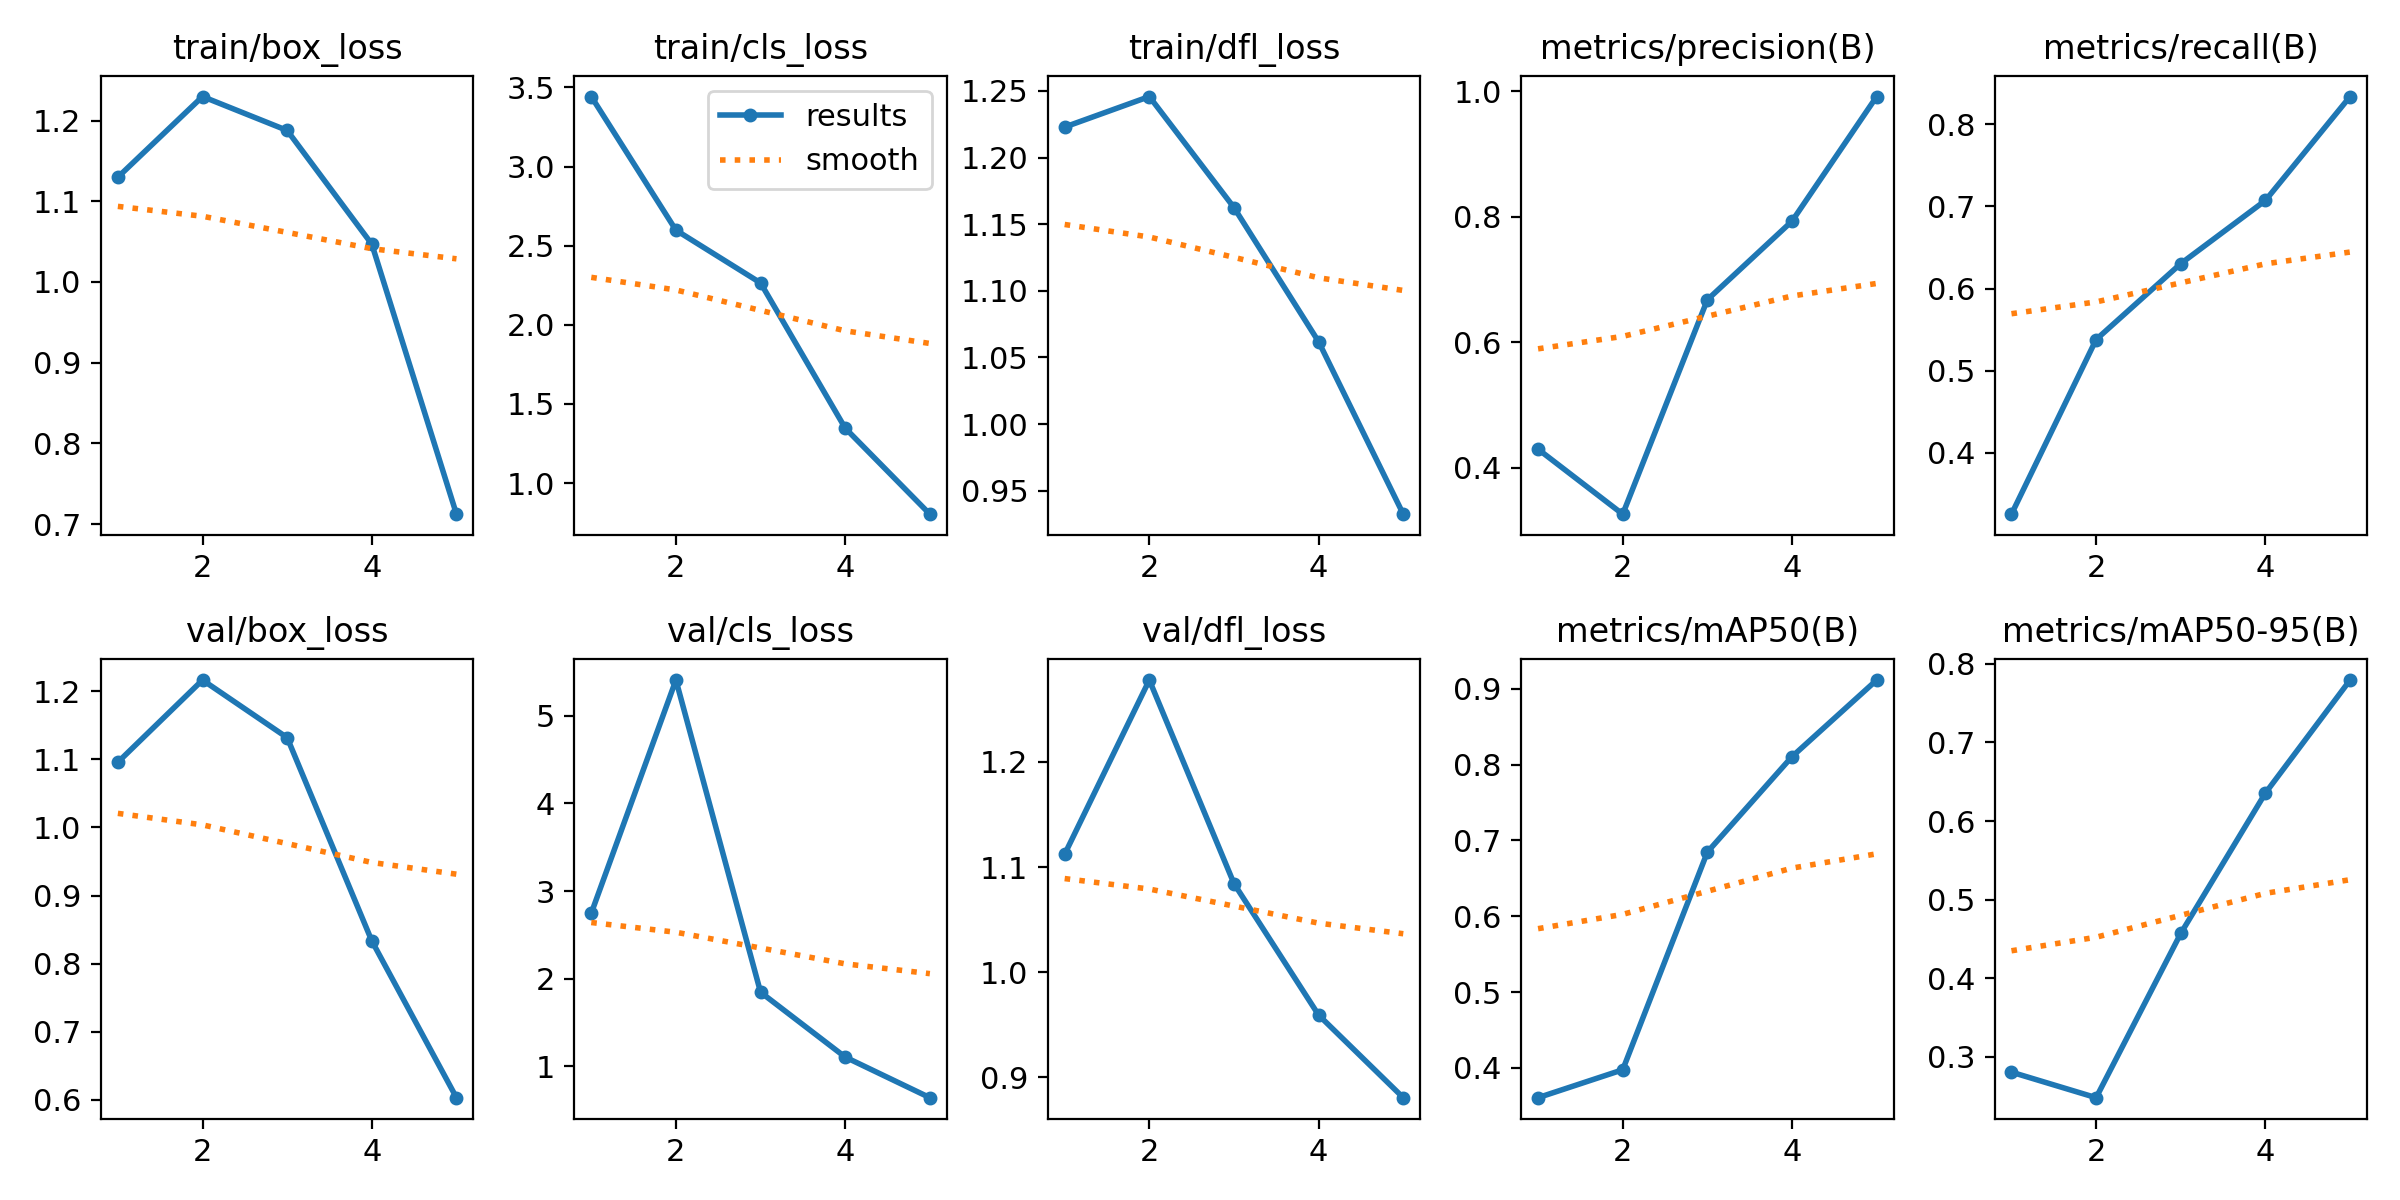

In [21]:
# The above training outputs final metrics in this format:
# Model summary (fused): 168 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
#                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:06<00:00,  1.39s/it]
#                   all        138        136      0.978      0.993      0.993       0.98

#      mAP50
# The  0.993  score is most important, but for this training that uses soley
# synthetic data, this high mAP50 score doesn't necesarily mean it works that well
# on real world images. We'll have to test this model next to see how well it performs
# in the real world.

# You can look at these graphs to check for any errors in the training.
import glob
from IPython.display import Image
matches = sorted(glob.glob(str(OUTPUT_DIR / 'runs/detect/train*/results.png')))
if matches:
    display(Image(matches[-1]))
else:
    print('Results image not found. Training may not have completed successfully.')

# In depth information is at https://falcon.duality.ai/secure/documentation/ex3-colab-training-output
# On any graphs that say "loss", you should see a downward trend. If loss starts
# trending up, that means your model is getting worse and you should adjust your
# learning rate

# Precision and Recall should have an upward trend. If the data shoots up and flatlines,
# you are probably overfitting and need more variety in your dataset.

# The mAP50 trend is displayed. It should also have an upward trend, and if it
# starts trending back down, there is a problem

# Creating synthetic data in FalconEditor allows you to adjust your scenario if
# your training has any of these pitfalls, making getting effective training
# data easy, cheap, and accessible.

In [ ]:
# In order to see how the model performs in the physical world, we must test it
# on images from the physcial world.

# Run the test scipt by pressing "play" on this cell.
# This script tells the YOLO model to look at the images in the testImages
# folder and make predictions.

# If this isn't the first time you're run this training,
# the system will prompt you to select which model you'd like to validate. Just
# choose the highest number to test the latest.

# When this is finished, you can find the prediction images
# in ./syntheticDataWorks_multiclass/Output/predictions')
# You can find the training and testing metrics and graphs in
# ./syntheticDataWorks_multiclass/Output/runs/detect/. The train folder is from the training
# and the val folder is from the testing.
%run predict.py

Select the training folder:
0: train
1: train-2
2: train-3
3: train-4
4: train2
5: train3
6: train4
7: train5
Select the training folder:
0: train
1: train-2
2: train-3
3: train-4
4: train2
5: train3
6: train4
7: train5


In [ ]:
# Generate the final report and save output to report/generatedreport.d
!python ../report/report.py

Generated report: /content/drive/MyDrive/syntheticDataWorks_multiclass/report/generatedreport.md
Copied training graph: train_results.png


In [ ]:
# Again, this process outputs this data:
# val: New cache created: /content/drive/MyDrive/Colab Notebooks/syntheticDataWorks_multiclass/testImages/labels.cache
#                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 11/11 [00:13<00:00,  1.22s/it]
#                   all        164        164      0.934       0.87      0.952      0.828

#      mAP50
# The  0.952  score shows that the training worked, and your model can detect the soup can in a real world setting. Congrats!

# Run this cell to see a grid of the prediction images!

import glob
from IPython.display import Image
pred_imgs = sorted(glob.glob(str(OUTPUT_DIR / 'predictions/images/*')))
if pred_imgs:
    display(Image(pred_imgs[0]))
else:
    print('No prediction images found. Run predict.py first.')

# You can see the full size, annotated predictions of the real world images here:
# ./syntheticDataWorks_multiclass/Output/predictions


FileNotFoundError: No such file or directory: '/content/drive/MyDrive/syntheticDataWorks_multiclass/Output/runs/detect/val/val_batch2_pred.jpg'

FileNotFoundError: No such file or directory: '/content/drive/MyDrive/syntheticDataWorks_multiclass/Output/runs/detect/val/val_batch2_pred.jpg'

<IPython.core.display.Image object>

In [ ]:
# Distance analysis is removed because no additional distance data is provided.
# Continue with prediction, reporting, and visualization using the copied project data.